In [2]:
# importando as bibliotecas que vai usar
import tensorflow as tf
import keras
import matplotlib
import numpy as np

2026-02-24 18:35:44.037473: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 18:35:44.255488: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 18:35:48.358740: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
from tensorflow.keras.datasets import mnist # Base de dados MNIST
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras import utils as np_utils
import matplotlib.pyplot as plt

In [4]:
(X_treinamento, y_treinamento), (X_teste, y_teste) = mnist.load_data() # fazendo o carregamento dos dados

Text(0.5, 1.0, 'Classe 5')

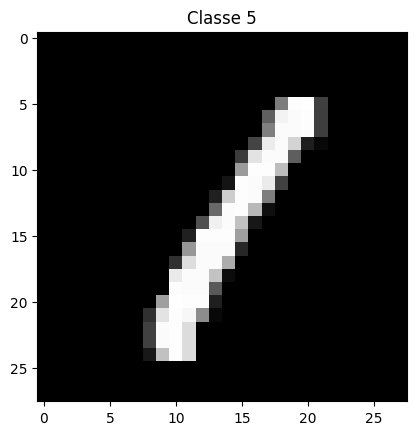

In [5]:
plt.imshow(X_treinamento[3], cmap='gray')
plt.title('Classe ' + str(y_treinamento[0]))

In [6]:
# pré-processamento
X_treinamento = X_treinamento.reshape(X_treinamento.shape[0], 28, 28, 1).astype('float32') / 255
X_teste = X_teste.reshape(X_teste.shape[0], 28, 28, 1).astype('float32') / 255

In [7]:
y_treinamento = np_utils.to_categorical(y_treinamento, 10) # one hot encoding
y_teste = np_utils.to_categorical(y_teste, 10)

In [8]:
# criação da rede neural
rede_neural = Sequential()
rede_neural.add(InputLayer(shape=(28, 28, 1))) # camada de entrada
rede_neural.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu')) # camada convolucional
rede_neural.add(MaxPooling2D(pool_size=(2, 2))) # camada de pooling
rede_neural.add(Flatten()) # transforma a matriz em vetor
rede_neural.add(Dense(units=128, activation='relu')) # camada densa
rede_neural.add(Dense(units=10,  activation='softmax'))# camada de saída

2026-02-24 18:36:01.127646: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
rede_neural.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# compilação e treinamento
rede_neural.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
rede_neural.fit(X_treinamento, y_treinamento, batch_size=128,epochs=5, validation_data=(X_teste, y_teste))

Epoch 1/5


2026-02-24 17:59:42.400635: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.6259 - loss: 1.3327 - val_accuracy: 0.8562 - val_loss: 0.5332
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8736 - loss: 0.4386 - val_accuracy: 0.8937 - val_loss: 0.3671
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8958 - loss: 0.3547 - val_accuracy: 0.9079 - val_loss: 0.3209
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9054 - loss: 0.3222 - val_accuracy: 0.9130 - val_loss: 0.2944
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9123 - loss: 0.2990 - val_accuracy: 0.9173 - val_loss: 0.2803


In [12]:
resultado = rede_neural.evaluate(X_teste, y_teste)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9173 - loss: 0.2803


In [13]:
resultado

[0.2802967429161072, 0.9172999858856201]